# Entrenamiento Transformer

En este notebook se entrena el transformer diseñado en transformer.py

In [1]:
#Importacion librerias
from google.colab import drive
from google.colab import files
from tqdm.notebook import tqdm
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from torchvision.transforms import ToTensor
import sys
from sklearn.model_selection import train_test_split
import torch.nn as nn

drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/MyDrive/TFG Matemáticas/TranslatorEn2Es')


ModuleNotFoundError: No module named 'google'

In [18]:
#Rutas donde se encuentran nuestros propios .py
from transformer import Transformer, TransformerConfig
from data import TranslationDataset
from data import TranslatorTokenizer

vocab_path = "/content/drive/MyDrive/TFG Matemáticas/TranslatorEn2Es/vocab_16k.json"
results_path = "/content/drive/MyDrive/TFG Matemáticas/TranslatorEn2Es/runs/run_2/"

# Descargamos el dataset OPUS-100

In [3]:
from datasets import load_dataset
dataset = load_dataset("opus100", "en-es")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-es/test-00000-of-00001.parquet:   0%|          | 0.00/237k [00:00<?, ?B/s]

en-es/train-00000-of-00001.parquet:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

en-es/validation-00000-of-00001.parquet:   0%|          | 0.00/238k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})

In [4]:
import pandas as pd

train = pd.DataFrame(dataset['train']['translation'])
val = pd.DataFrame(dataset['validation']['translation'])
#test = pd.DataFrame(dataset['test']['translation'])

train.head()

,en,es
0,"It was the asbestos in here, that's what did it!",Fueron los asbestos aquí. ¡Eso es lo que ocurrió!
1,I'm out of here.,Me voy de aquí.
2,"One time, I swear I pooped out a stick of chalk.","Una vez, juro que cagué una barra de tiza."
3,"And I will move, do you understand me?","Y prefiero mudarme, ¿Entiendes?"
4,"- Thank you, my lord.",- Gracias.


#Filtrado del dataset

In [5]:
def filter_dataset(dataframe):
    """
    Filtra el dataset, mismo que en dataset.ipynb
    """
    df = dataframe.dropna().copy()
    df = df.drop_duplicates(subset=['en','es'])


    #Texto sin espacios y en minuscula
    en_text = df['en'].str.lower().str.strip()
    es_text = df['es'].str.lower().str.strip()

    #Longitudes de las frases
    long_en = df['en'].str.split().str.len()
    long_es = df['es'].str.split().str.len()
    ratio = long_es / long_en

    #Mascaras
    not_empy = (en_text != "") & (es_text != "")
    not_equal = (en_text != es_text)
    ming_len = (long_en >= 3) & (long_es >= 3)
    max_len = (long_en <= 64) & (long_es <= 64)
    m_ratio = (ratio > 0.5) & (ratio < 2.0)


    #Filtro
    mask = not_empy & not_equal & ming_len & m_ratio & max_len
    return df[mask]

train = filter_dataset(train)
print(f"Dataset final: {len(train)}")

Dataset final: 749103


# GPU

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
!nvidia-smi

Wed Apr 15 08:48:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             43W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Tokenizar y Transformador

In [19]:
#CARGAMOS TOKENIZADOR (tarda un poco porque carga todo en RAM)
tokenizer = TranslatorTokenizer(vocab_path,context_length=128)
train_loader  =  DataLoader(TranslationDataset(train,tokenizer), batch_size=128, shuffle=True)
val_loader = DataLoader(TranslationDataset(val,tokenizer), batch_size=128, shuffle=False)
print(f"Tamaño vocabulario: {len(tokenizer)}")

Tamaño vocabulario: 16000


In [20]:
from train import Trainer


def init_weights(m):
    """
    Función de inicialización profesional para arquitecturas Transformer.
    Xavier Uniform es ideal para mantener la varianza constante en capas lineales
    """
    if isinstance(m, nn.Linear):
        #
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            # Los sesgos (biases) se inicializan siempre a cero
            nn.init.constant_(m.bias, 0)

    elif isinstance(m, nn.Embedding):
        # Los embeddings suelen inicializarse con una normal de desviación pequeña (0.02)
        # Esto asegura que los vectores iniciales no estén demasiado dispersos
        nn.init.normal_(m.weight, mean=0.0, std=0.02)

    elif isinstance(m, nn.LayerNorm):
        # LayerNorm debe empezar con ganancia 1 y sesgo 0 para ser neutra al inicio
        nn.init.constant_(m.weight, 1.0)
        nn.init.constant_(m.bias, 0)



config = TransformerConfig(vocab_size=len(tokenizer), pad_id=tokenizer.pad_id)
model = Transformer(config).to(device)
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    results_path=results_path,
    patience=3
)

model.apply(init_weights)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total de parámetros entrenables: {total_params / 1_000_000:.2f} M")

Total de parámetros entrenables: 19.73 M


ENTRENAMIENTO


In [21]:
#Ejecutar si continuar con entrenamiento
last_checkpoint = results_path + "best_model_epoch_24_val_1.8253.pth"
trainer.load_checkpoint(last_checkpoint)

Reanudando desde la época 24 | Mejor Val Loss histórico: 1.8362


In [ ]:
# Arrancamos
trainer.train(total_epochs=50)

Training:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 25/50:   0%|          | 0/5853 [00:00<?, ?it/s]

Nuevo mejor modelo guardado en epoca 25
Epoch 25 | Train: 1.5689 | Val: 1.8163 | LR: 0.000163



Epoch 26/50:   0%|          | 0/5853 [00:00<?, ?it/s]

Nuevo mejor modelo guardado en epoca 26
Epoch 26 | Train: 1.5514 | Val: 1.8156 | LR: 0.000160



...

Epoch 35/50:   0%|          | 0/5853 [00:00<?, ?it/s]

Nuevo mejor modelo guardado en epoca 35
Epoch 35 | Train: 1.4408 | Val: 1.7813 | LR: 0.000138



Epoch 36/50:   0%|          | 0/5853 [00:00<?, ?it/s]

Epoch 36 | Train: 1.4317 | Val: 1.7830 | LR: 0.000136



Epoch 37/50:   0%|          | 0/5853 [00:00<?, ?it/s]

# Progreso Entrenamiento

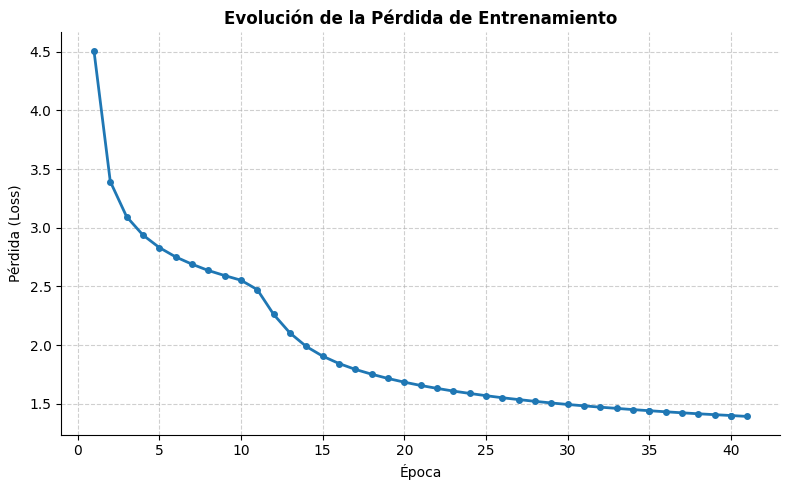

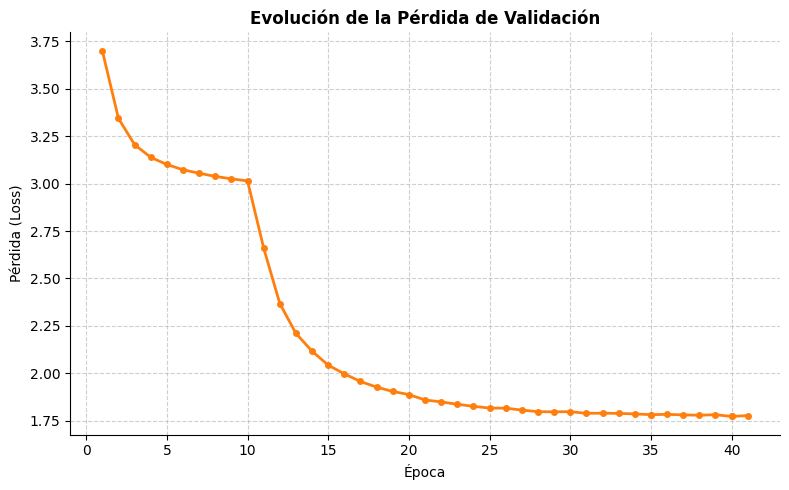

In [ ]:
from config import RUNS_PATH,MEDIA_PATH
import os
import re
import matplotlib.pyplot as plt

loss_progress = os.path.join(RUNS_PATH,"loss.txt")


def extraer_datos_log(ruta_archivo):
    """
    Lee el archivo de texto y extrae las métricas.
    Retorna 3 listas independientes: (epocas, train_losses, val_losses).
    """
    epocas = []
    train_losses = []
    val_losses = []

    # Patrón que detecta tanto "Train Loss:" como "Train:"
    patron = re.compile(r"Epoch\s+(\d+).*?(?:Train(?: Loss)?):\s*([\d.]+).*?(?:Val(?: Loss)?):\s*([\d.]+)")

    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
            for linea in archivo:
                coincidencia = patron.search(linea)
                if coincidencia:
                    epocas.append(int(coincidencia.group(1)))
                    train_losses.append(float(coincidencia.group(2)))
                    val_losses.append(float(coincidencia.group(3)))
                    
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en '{ruta_archivo}'.")
    
    return epocas, train_losses, val_losses

def graficar_metrica(x, y, titulo, color='#1f77b4', guardar_como=None):
    """
    Toma una lista de X y una de Y y dibuja una gráfica independiente.
    Si le pasas un nombre a 'guardar_como', guardará la imagen en tu PC.
    """
    if not x or not y:
        print(f"No hay datos para graficar: {titulo}")
        return

   
    plt.figure(figsize=(8, 5))
    
    # Dibujar la línea
    plt.plot(x, y, color=color, marker='o', markersize=4, linewidth=2)
    
    
    plt.title(titulo, fontsize=12, fontweight='bold')
    plt.xlabel('Época', fontsize=10)
    plt.ylabel('Pérdida (Loss)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()


    if guardar_como:
        plt.savefig(guardar_como, dpi=300) 
       

    # Mostrar la gráfica en pantalla
    plt.show()


epocas, loss_entrenamiento, loss_validacion = extraer_datos_log(loss_progress)

    # 2. Si quieres mostrar SOLO el entrenamiento:
graficar_metrica(
    x=epocas, 
    y=loss_entrenamiento, 
    titulo='Evolución de la Pérdida de Entrenamiento', 
    color='#1f77b4',           # Azul
    guardar_como=os.path.join(MEDIA_PATH,'train_loss.png') # Esto guardará la foto en HD para tu memoria
)

# 3. Y luego, cuando tú decidas, graficas SOLO la validación:
graficar_metrica(
    x=epocas, 
    y=loss_validacion, 
    titulo='Evolución de la Pérdida de Validación', 
    color='#ff7f0e',           # Naranja
    guardar_como=os.path.join(MEDIA_PATH,'val_loss.png')
)

#42 epochs 8-9 horas